# Eksperimen SML - Prediksi Customer Churn
**Nama:** Iqbal Rahmatullah
**Dataset:** Telco Customer Churn (7043 baris, 21 kolom, target biner `Churn`)

Notebook ini mengikuti struktur Template Eksperimen MSML: Data Loading -> EDA -> Preprocessing.
Hasil akhir notebook ini dikonversi menjadi `automate_Iqbal-Rahmatullah.py` untuk preprocessing otomatis.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Data Loading
Dataset mentah diambil dari `namadataset_raw/telco_customer_churn_raw.csv`.

In [2]:
RAW_PATH = "../namadataset_raw/telco_customer_churn_raw.csv"
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Value & Duplikat

In [5]:
print("Jumlah data duplikat:", df.duplicated().sum())
print("Jumlah customerID unik:", df["customerID"].nunique(), "dari", len(df), "baris")

# TotalCharges terbaca sebagai string karena ada whitespace/blank pada baris tertentu
blank_total_charges = df["TotalCharges"].apply(lambda x: str(x).strip() == "").sum()
print("Baris TotalCharges kosong (whitespace):", blank_total_charges)
df.isna().sum()

Jumlah data duplikat: 0
Jumlah customerID unik: 7043 dari 7043 baris
Baris TotalCharges kosong (whitespace): 11


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Konversi eksplorasi (khusus EDA, tidak mengubah df utama)
tc_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing value setelah coercion ke numeric:", tc_numeric.isna().sum())
df.loc[tc_numeric.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Missing value setelah coercion ke numeric: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Seluruh baris dengan `TotalCharges` kosong memiliki `tenure` = 0 (pelanggan baru), jadi nilai tersebut wajar diisi 0 saat preprocessing.

### 3.2 Distribusi Target (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Persentase churn: 26.54 %


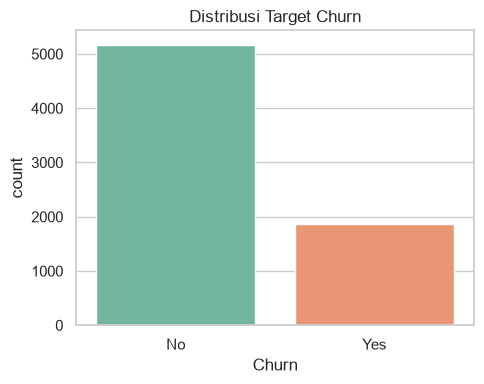

In [7]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print("Persentase churn:", round(churn_counts["Yes"] / len(df) * 100, 2), "%")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Distribusi Target Churn")
plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=100)
plt.show()

Target tidak seimbang (~73% No, ~27% Yes) namun tidak ekstrem, sehingga masih layak dilatih tanpa teknik resampling khusus.

### 3.3 Distribusi Fitur Numerik

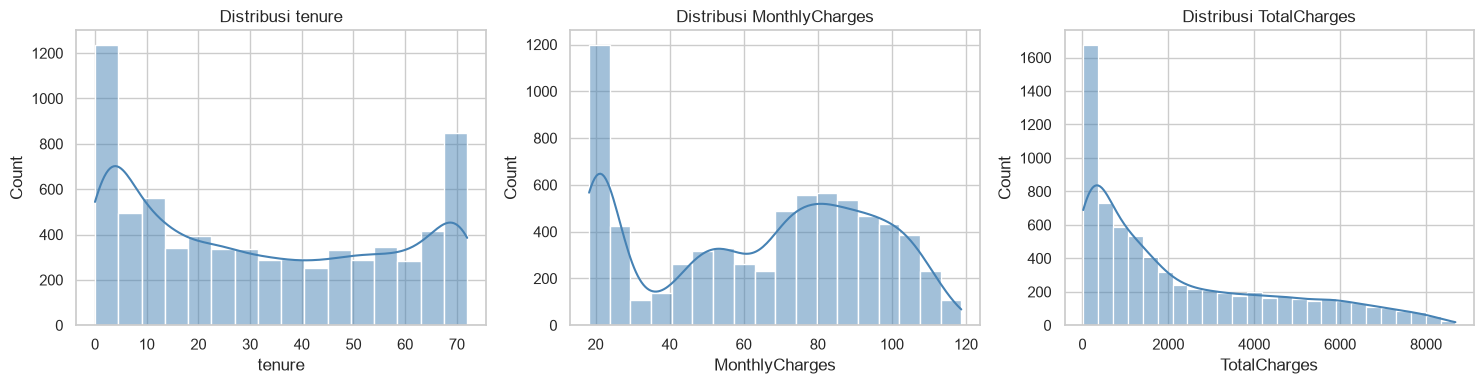

In [8]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df_num = df.copy()
df_num["TotalCharges"] = pd.to_numeric(df_num["TotalCharges"], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df_num[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.savefig("eda_numeric_distribution.png", dpi=100)
plt.show()

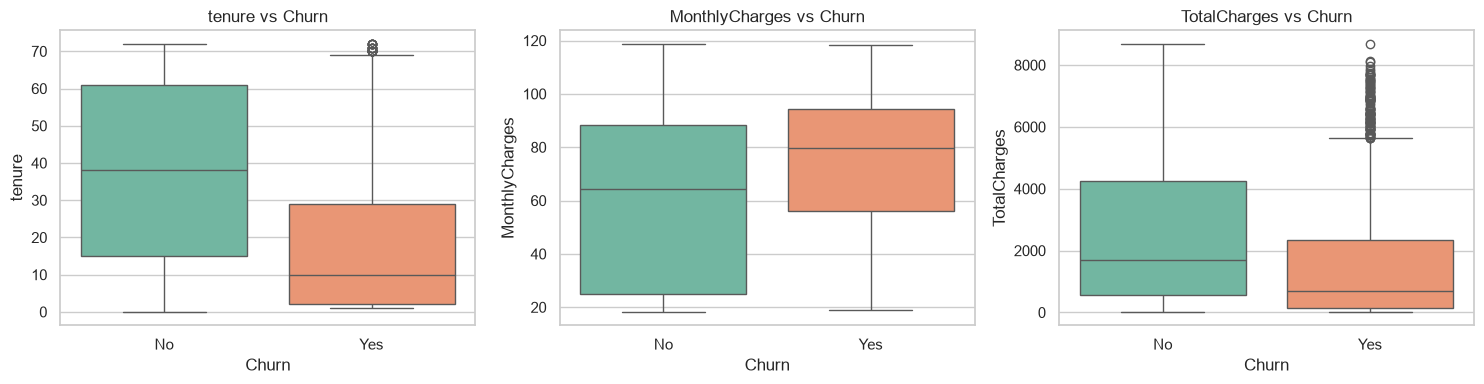

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_num, x="Churn", y=col, hue="Churn", palette="Set2", ax=ax, legend=False)
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
plt.savefig("eda_numeric_vs_churn.png", dpi=100)
plt.show()

Pelanggan dengan `tenure` rendah dan `MonthlyCharges` tinggi cenderung lebih banyak yang churn.

### 3.4 Fitur Kategorikal vs Churn

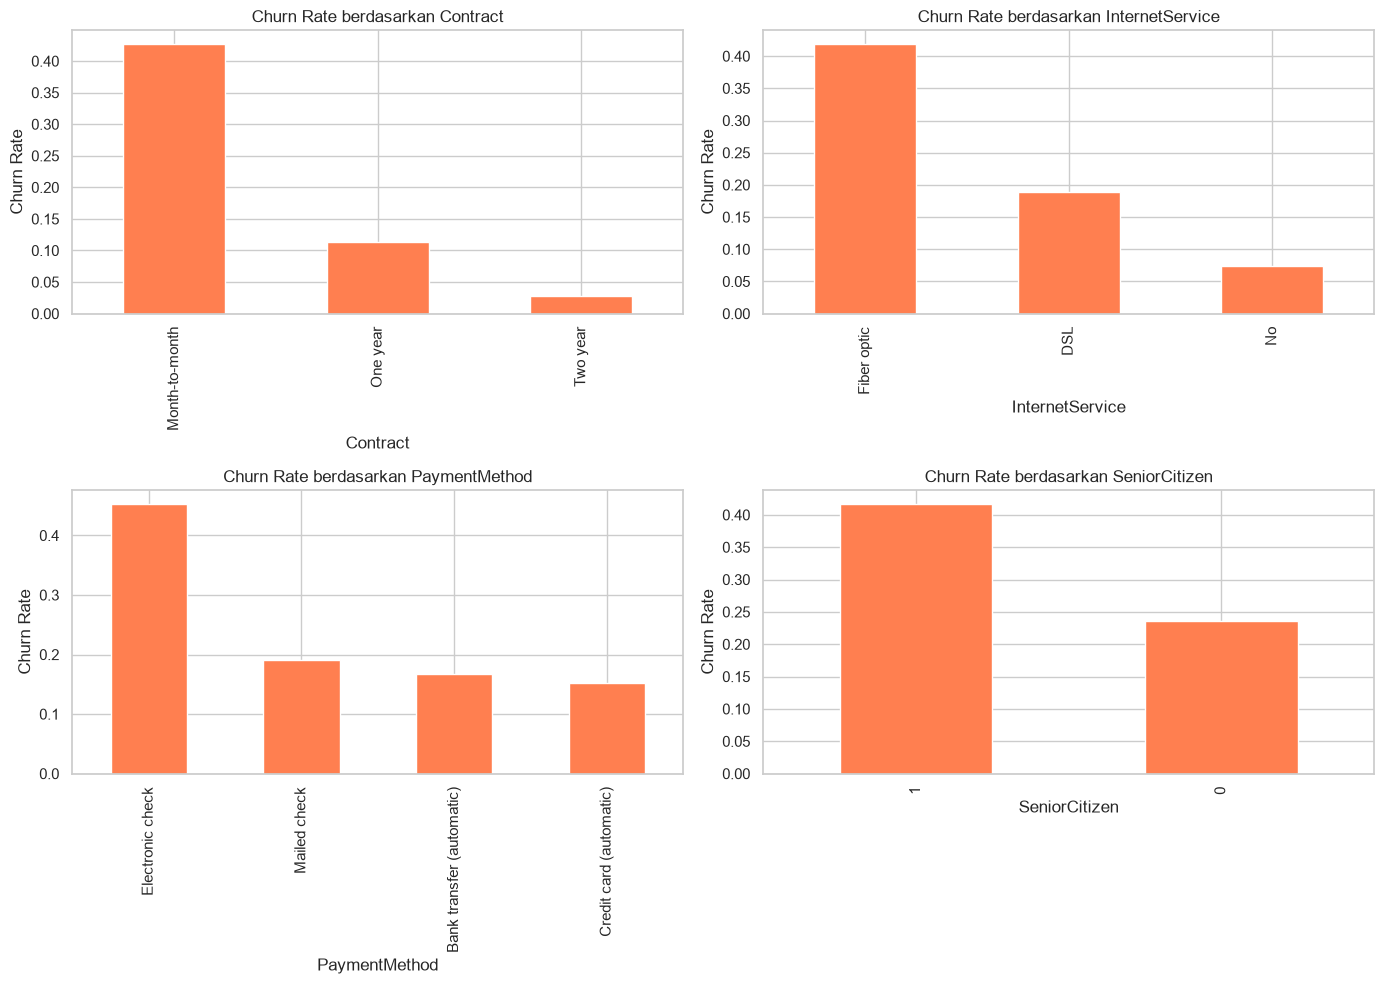

In [10]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean())
    churn_rate.sort_values(ascending=False).plot(kind="bar", ax=ax, color="coral")
    ax.set_ylabel("Churn Rate")
    ax.set_title(f"Churn Rate berdasarkan {col}")
plt.tight_layout()
plt.savefig("eda_categorical_vs_churn.png", dpi=100)
plt.show()

Kontrak `Month-to-month`, layanan `Fiber optic`, dan metode bayar `Electronic check` berasosiasi dengan churn rate lebih tinggi.

### 3.5 Korelasi Fitur Numerik

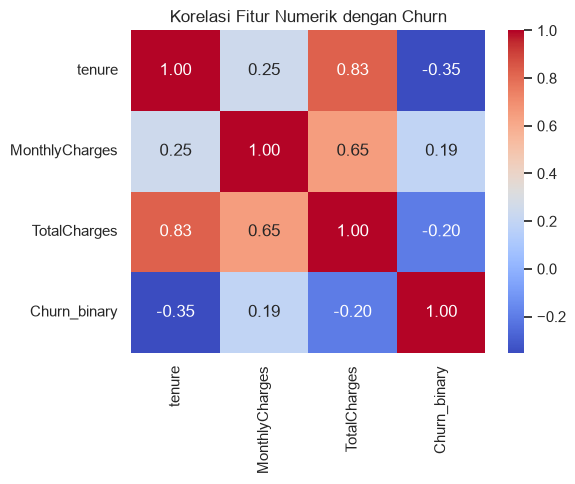

In [11]:
df_corr = df_num.copy()
df_corr["Churn_binary"] = (df_corr["Churn"] == "Yes").astype(int)
corr = df_corr[num_cols + ["Churn_binary"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Fitur Numerik dengan Churn")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=100)
plt.show()

## 4. Data Preprocessing (Manual)
Tahapan berikut nantinya dikonversi menjadi fungsi otomatis pada `automate_Iqbal-Rahmatullah.py`.

### 4.1 Handling Missing Value & Tipe Data

In [12]:
df_clean = df.copy()
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)
print("Missing value tersisa:", df_clean.isna().sum().sum())

Missing value tersisa: 0


### 4.2 Drop Kolom Tidak Relevan

In [13]:
df_clean = df_clean.drop(columns=["customerID"])
df_clean.shape

(7043, 20)

### 4.3 Encoding Target

In [14]:
df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1})
df_clean["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 4.4 Encoding Fitur Kategorikal (One-Hot Encoding)

In [15]:
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
print("Kolom kategorikal:", categorical_cols)

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded.shape

Kolom kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


(7043, 31)

### 4.5 Train-Test Split

In [16]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5634, 30)  Test: (1409, 30)


### 4.6 Feature Scaling

In [17]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.262257,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False
3151,0,-0.711743,0.337478,-0.503635,True,True,True,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4860,0,-0.793155,-0.809013,-0.749883,True,True,True,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True
3867,0,-0.263980,0.284384,-0.172722,False,True,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,True,True,True,False,False
3810,0,-1.281624,-0.676279,-0.989374,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### 4.7 Simpan Dataset Hasil Preprocessing

In [18]:
import os

OUT_DIR = "telco_customer_churn_preprocessing"
os.makedirs(OUT_DIR, exist_ok=True)

train_df = X_train.copy()
train_df["Churn"] = y_train.values
test_df = X_test.copy()
test_df["Churn"] = y_test.values

train_df.to_csv(f"{OUT_DIR}/train.csv", index=False)
test_df.to_csv(f"{OUT_DIR}/test.csv", index=False)

print("Tersimpan di:", OUT_DIR)
print("train.csv:", train_df.shape, " test.csv:", test_df.shape)

Tersimpan di: telco_customer_churn_preprocessing
train.csv: (5634, 31)  test.csv: (1409, 31)


## 5. Kesimpulan
- Dataset final memiliki fitur numerik ter-scale dan fitur kategorikal ter-encode, siap dipakai untuk pelatihan model pada tahap **Membangun Model Machine Learning**.
- Langkah-langkah pada bagian 4 dikonversi menjadi fungsi otomatis di `automate_Iqbal-Rahmatullah.py`.